In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (8, 6) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load adverts dataset from google drive

advt = pd.read_csv('/content/drive/MyDrive/adverts.csv')
advt.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [4]:
advt.shape

(402005, 12)

In [5]:
advt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


In [6]:
#show all unique values
for column in advt.columns:
  n_unique = advt[column].nunique()
  if advt[column].nunique() <= 85:
    print(f'{column} ({n_unique}): {advt[column].unique()}\n')
  else:
    print(f'{column} ({n_unique})\n')

public_reference (402005)

mileage (80634)

reg_code (72): [nan '61' '17' '16' '64' '13' '08' '19' '60' '69' '66' '12' '18' '65' '09'
 'B' '10' '14' '03' '67' '63' '15' '68' '56' '20' '70' '62' '11' '05' '59'
 '58' 'W' '02' '57' '06' '52' '53' '04' 'J' '07' '55' '51' 'X' 'D' 'S' 'Y'
 '54' 'H' 'K' 'E' 'L' 'V' 'M' 'G' 'T' 'N' 'P' 'A' 'F' 'R' 'C' '94' '85'
 'CA' 'm' 'FW' '723xuu' '95' 's' '38' 'k' '37' 'p']

standard_colour (22): ['Grey' 'Blue' 'Brown' 'Red' 'Bronze' 'Black' 'White' 'Silver' nan
 'Purple' 'Green' 'Orange' 'Yellow' 'Turquoise' 'Gold' 'Multicolour'
 'Beige' 'Burgundy' 'Pink' 'Maroon' 'Magenta' 'Navy' 'Indigo']

standard_make (110)

standard_model (1168)

vehicle_condition (2): ['NEW' 'USED']

year_of_registration (84): [  nan 2011. 2017. 2016. 2015. 2013. 2008. 2019. 2010. 2012. 2018. 2009.
 1984. 2014. 2003. 2006. 2020. 2005. 2000. 2002. 2007. 2004. 1991. 2001.
 1986. 1998. 1990. 1993. 1987. 1994. 1999. 1970. 1988. 1995. 1997. 1969.
 1992. 1989. 1996. 1976. 1983. 1980. 197

In [7]:
# We remove public reference column

advt = advt.drop('public_reference', axis=1)


In [8]:
#Descriptive Stats.
advt[['mileage','year_of_registration','price']].describe().round()

,mileage,year_of_registration,price
count,401878.0,368694.0,402005.0
mean,37744.0,2015.0,17342.0
std,34832.0,8.0,46437.0
min,0.0,999.0,120.0
25%,10481.0,2013.0,7495.0
50%,28630.0,2016.0,12600.0
75%,56876.0,2018.0,20000.0
max,999999.0,2020.0,9999999.0


In [9]:
advt[['standard_colour','fuel_type','body_type','standard_make','standard_model','vehicle_condition']].describe()

,standard_colour,fuel_type,body_type,standard_make,standard_model,vehicle_condition
count,396627,401404,401168,402005,402005,402005
unique,22,9,16,110,1168,2
top,Black,Petrol,Hatchback,BMW,Golf,USED
freq,86287,216929,167315,37376,11583,370756


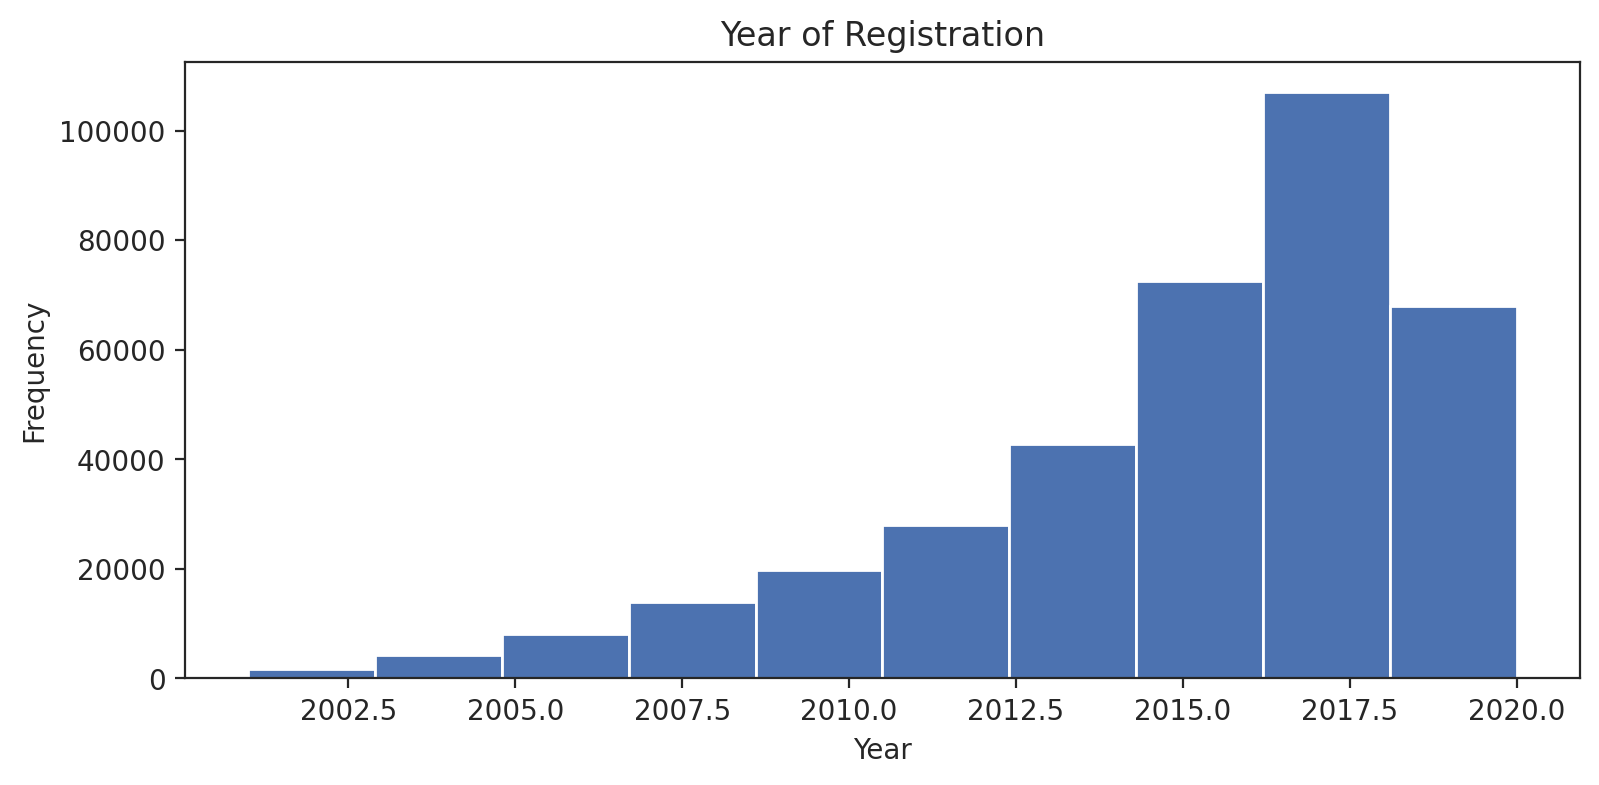

In [10]:
#Examine data distributions
plt.figure(figsize=(9, 4))
advt_sub = advt[advt['year_of_registration'] >= 2001]
advt_sub['year_of_registration'].plot.hist();
plt.title('Year of Registration')
plt.xlabel('Year')
plt.show()

In [11]:
advt.loc[advt['year_of_registration']<2001]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
25,49585.0,B,NaN,Ferrari,308,USED,1984.0,54475,Convertible,False,Petrol
280,171000.0,W,Red,Toyota,Yaris Verso,USED,2000.0,495,Hatchback,False,Petrol
312,44163.0,W,Silver,Volkswagen,Beetle,USED,2000.0,1100,Hatchback,False,Petrol
426,175000.0,J,Blue,Mercedes-Benz,SEC Series,USED,1991.0,19990,Coupe,False,Petrol
667,99000.0,X,Blue,Volvo,V40,USED,2000.0,1295,Estate,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
400664,5800.0,A,Blue,Fiat,500,USED,1963.0,9500,Saloon,False,Petrol
400710,150000.0,R,Green,Toyota,Picnic,USED,1998.0,1495,MPV,False,Petrol
400724,0.0,L,Silver,Porsche,911,USED,1973.0,175000,NaN,False,Petrol
401128,36000.0,M,White,Rolls-Royce,Silver Shadow,USED,1973.0,7495,Saloon,False,Petrol


In [12]:
advt['year_of_registration'].mode()

,year_of_registration
0,2017.0


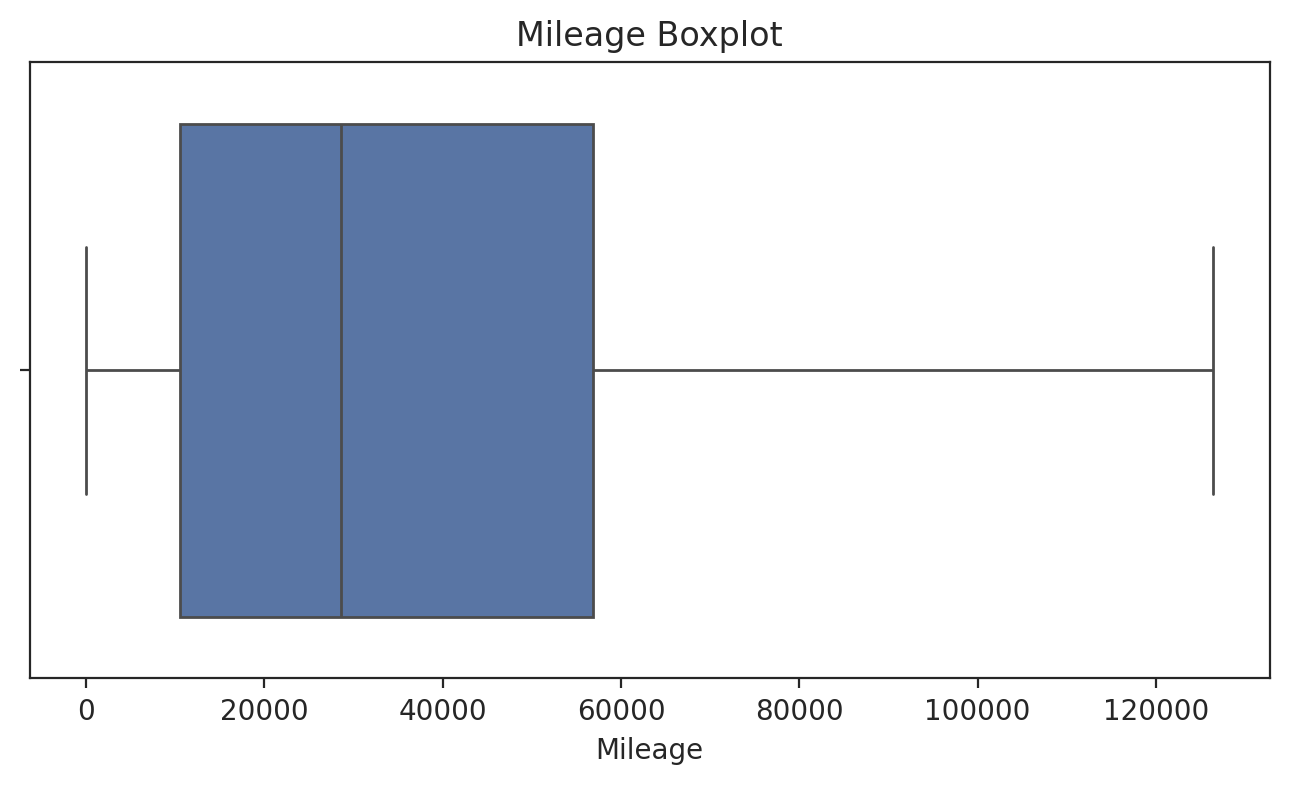

In [13]:
#Boxplot of mileage data
plt.figure(figsize=(8, 4))
sns.boxplot(x='mileage', data=advt, showfliers=False)
plt.title('Mileage Boxplot')
plt.xlabel('Mileage')
plt.show()

In [14]:
#  Percentage of nulll values in the mileage column

null_percentage = (advt['mileage'].isnull().sum() / len(advt)) * 100
print(f'The mileage column has {null_percentage:.2f}% null values.')

The mileage column has 0.03% null values.


In [15]:
advt['reg_code'].describe()

,reg_code
count,370148
unique,72
top,17
freq,36738


In [16]:
advt['reg_code'].value_counts()

,count
reg_code,
17,36738
67,32230
66,25227
69,23825
18,21613
...,...
723xuu,1
FW,1
m,1


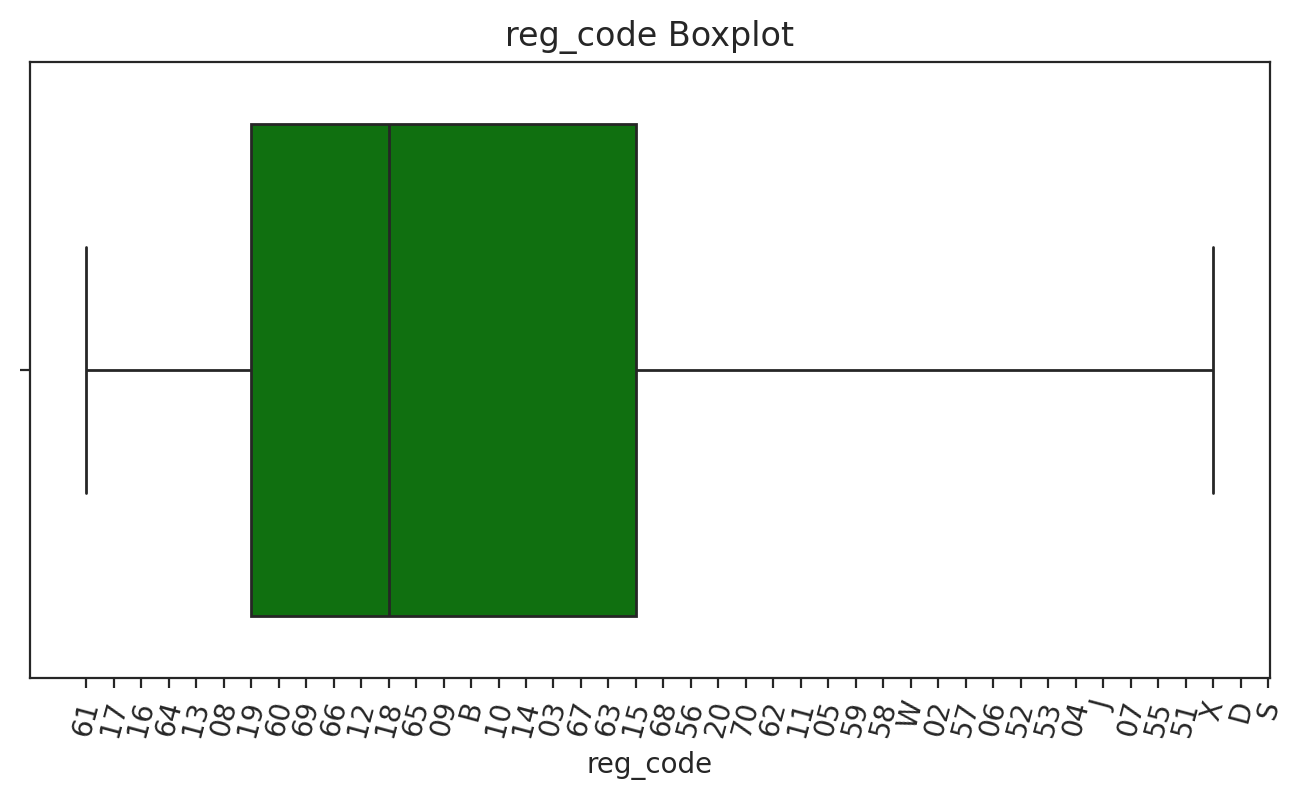

In [17]:
# reg_code boxplot

plt.figure(figsize=(8, 4))
sns.boxplot(x='reg_code', data=advt, showfliers=False, color='green')
plt.title('reg_code Boxplot')
plt.xlabel('reg_code')
plt.xticks(rotation=75)
plt.show()

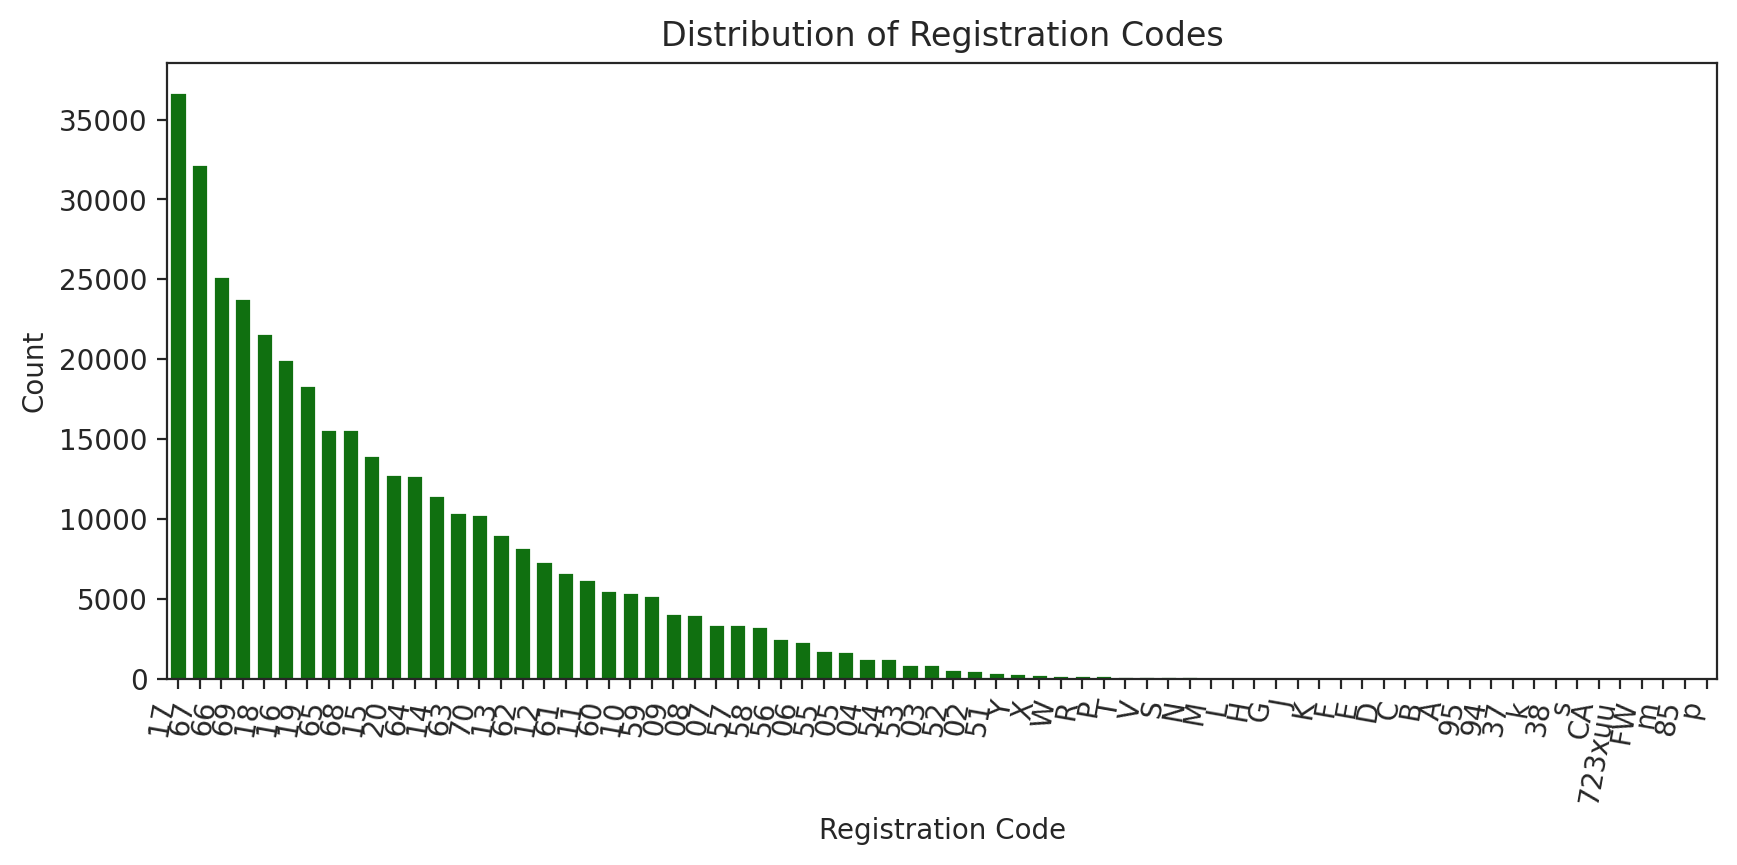

In [18]:
# Barplot of reg_code frequency data

reg_code_counts = advt['reg_code'].value_counts()

plt.figure(figsize=(10, 4))
sns.barplot(x=reg_code_counts.index, y=reg_code_counts.values, color='green')
plt.title('Frequency of Registration Codes')
plt.xlabel('Registration Code')
plt.ylabel('Count')
plt.title('Distribution of Registration Codes')
plt.xticks(rotation=80, ha='right')
plt.show()

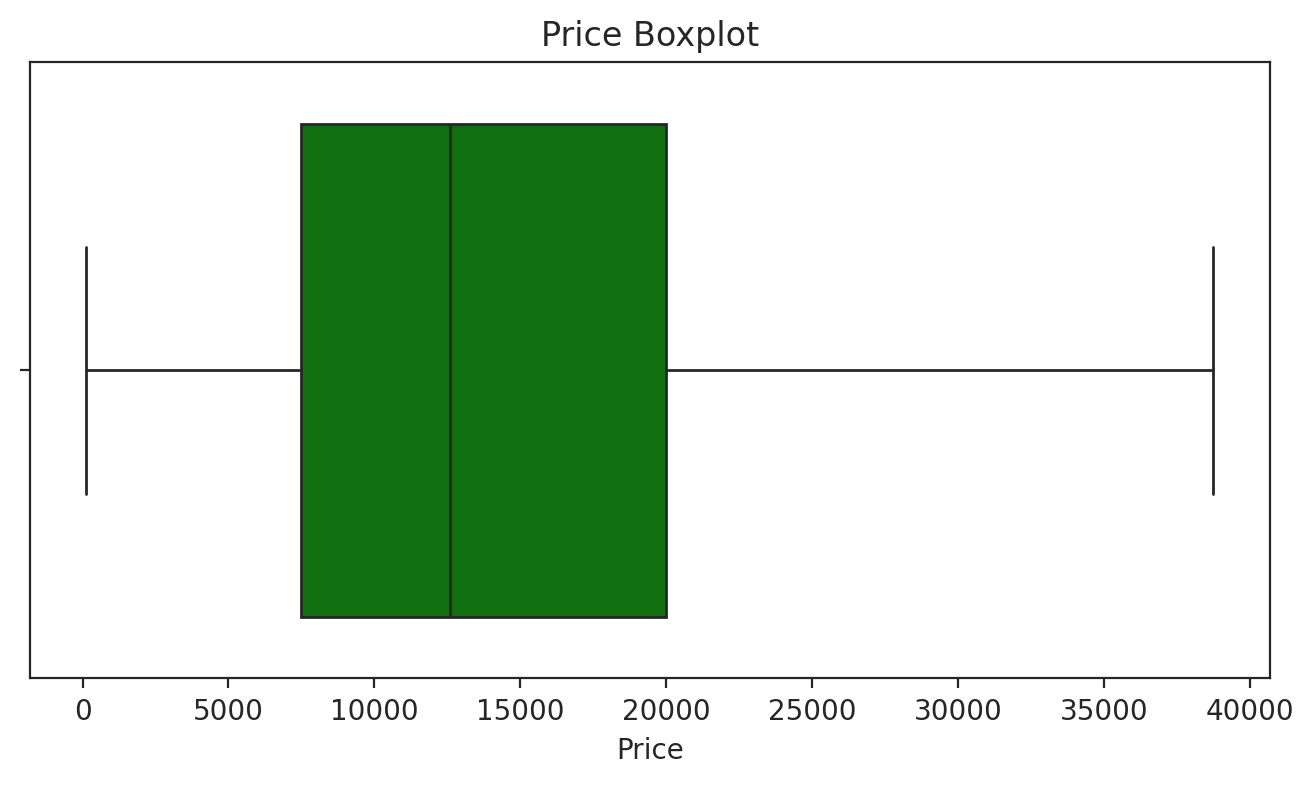

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='price', data=advt, color='green', showfliers=False)
plt.title('Price Boxplot')
plt.xlabel('Price')
plt.show()

In [20]:
advt['vehicle_condition'].value_counts(normalize=True)

,proportion
vehicle_condition,
USED,0.922267
NEW,0.077733


In [21]:
advt['standard_colour'].value_counts().head(10)

,count
standard_colour,
Black,86287
White,70535
Grey,68227
Blue,59784
Silver,49323
Red,42024
Green,4534
Orange,4088
Yellow,2097


In [22]:
#Examine frequency of most common colours.
top_6_colour = advt['standard_colour'].value_counts().nlargest(6)
print(f'The 6 most popular colours make up {top_6_colour.sum()/len(advt)*100:.2f}% of the data')

The 6 most popular colours make up 93.58% of the data


In [23]:
advt.isna().sum()

,0
mileage,127
reg_code,31857
standard_colour,5378
standard_make,0
standard_model,0
vehicle_condition,0
year_of_registration,33311
price,0
body_type,837
crossover_car_and_van,0


In [ ]:
null_percentage = (advt['year_of_registration'].isnull().sum() / len(advt)) * 100
print(f'The year of registration column has {null_percentage:.2f}% null values.')

The year of registration column has 8.29% null values.


In [ ]:
#Show null values for year_of_reg column
advt[advt['year_of_registration'].isnull()]


,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
17,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
19,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
37,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
44,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
401860,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
401890,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
401902,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol
401905,0.0,NaN,Red,Land Rover,Range Rover Evoque,NEW,NaN,44995,SUV,False,Petrol


In [ ]:
#Examine null values
advt.loc[(advt['vehicle_condition'] =='NEW')&(advt['year_of_registration'].isnull())&(advt['mileage']<200)]


,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
17,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
19,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
37,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
44,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
401860,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
401890,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
401902,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol
401905,0.0,NaN,Red,Land Rover,Range Rover Evoque,NEW,NaN,44995,SUV,False,Petrol


In [27]:
# If vehicle condition is new and mileage <200, we replace year of registration null values with the year of registration max value.

max_year = advt['year_of_registration'].max()

advt.loc[(advt['vehicle_condition'] == 'NEW') &
         (advt['year_of_registration'].isnull()) &
         (advt['mileage'] < 200), 'year_of_registration'] = max_year

In [28]:
advt['year_of_registration'].describe()

,year_of_registration
count,399943.000000
mean,2015.396389
std,7.761851
min,999.000000
25%,2014.000000
50%,2017.000000
75%,2018.000000
max,2020.000000


In [29]:
advt[advt['year_of_registration'].isnull()]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
54,30000.0,18.0,Red,Vauxhall,Insignia,USED,NaN,11990,Hatchback,False,Petrol
83,42847.0,61.0,Red,Honda,Jazz,USED,NaN,5695,Hatchback,False,Petrol
865,43130.0,66.0,White,Land Rover,Range Rover Sport,USED,NaN,35990,SUV,False,Diesel
968,63369.0,17.0,Blue,SKODA,Rapid Spaceback,USED,NaN,7490,Hatchback,False,Diesel
1256,18715.0,68.0,White,Volvo,V40,USED,NaN,16950,NaN,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
400536,40523.0,NaN,Red,Peugeot,108,USED,NaN,5999,Hatchback,False,Petrol
400725,45.0,20.0,Silver,Land Rover,Range Rover Evoque,USED,NaN,46945,SUV,False,Diesel
401314,12522.0,67.0,Red,Dacia,Sandero,USED,NaN,6300,Hatchback,False,Petrol
401323,46000.0,13.0,Grey,Volkswagen,Caravelle,USED,NaN,22995,MPV,False,Diesel


In [30]:

advt['reg_code'] = pd.to_numeric(advt['reg_code'], errors='coerce')


In [31]:
advt.loc[(advt['reg_code'] <= max_year-2000)
& (advt['year_of_registration'].isnull()), 'year_of_registration'] = 2000 + advt['reg_code']

In [32]:
advt.loc[((advt['reg_code'] > 50) & (advt['reg_code'] < 50 + (max_year-2000)))
& (advt['year_of_registration'].isnull()), 'year_of_registration'] = 2001 - 50 + advt['reg_code']

In [33]:
advt.loc[advt['year_of_registration'].isnull()]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1510,13406.0,NaN,White,Land Rover,Range Rover Evoque,USED,NaN,26000,Coupe,False,Diesel
2356,499.0,70.0,Silver,Volkswagen,Arteon,USED,NaN,34999,Estate,False,Petrol
2631,1000.0,NaN,Blue,Maserati,Levante,USED,NaN,63995,SUV,False,Petrol
4408,40.0,70.0,Red,Volvo,V60,USED,NaN,32980,Estate,False,Petrol
4766,NaN,NaN,Grey,Subaru,Outback,USED,NaN,35995,Estate,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
396985,29000.0,NaN,Black,Lamborghini,Gallardo,USED,NaN,77990,Coupe,False,Petrol
398337,25.0,70.0,Blue,Volvo,V60,USED,NaN,31990,Estate,False,Diesel
398645,22312.0,NaN,Silver,Lamborghini,Diablo,USED,NaN,139750,Coupe,False,Petrol
399728,12812.0,NaN,Silver,Rolls-Royce,Wraith,USED,NaN,159950,Coupe,False,Petrol


In [34]:
advt.loc[advt['year_of_registration'].isnull()].describe().round(2)

,mileage,reg_code,year_of_registration,price
count,569.00,213.00,0.0,584.00
mean,25072.10,70.23,NaN,158257.98
std,33058.84,4.72,NaN,1013845.13
min,0.00,37.00,NaN,675.00
25%,101.00,70.00,NaN,10990.75
50%,12145.00,70.00,NaN,24992.50
75%,40237.00,70.00,NaN,44995.00
max,219000.00,95.00,NaN,9999999.00


In [ ]:
# Fill remaining null values in 'year_of_registration' with the mean value. Not done due to creation of inconsistent data.
#mean_reg_year = advt['year_of_registration'].mean()
#advt['year_of_registration'].fillna(mean_reg_year, inplace=True)



In [ ]:
advt.loc[advt['year_of_registration']<1903]


,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
59010,14000.0,7.0,Blue,Toyota,Prius,USED,1007.0,7000,Hatchback,False,Petrol Hybrid
69516,96659.0,65.0,Black,Audi,A4 Avant,USED,1515.0,10385,Estate,False,Diesel
84501,37771.0,63.0,Black,Smart,fortwo,USED,1063.0,4785,Coupe,False,Petrol
114737,30000.0,59.0,Red,Toyota,AYGO,USED,1009.0,4695,Hatchback,False,Petrol
120858,27200.0,66.0,Black,MINI,Clubman,USED,1016.0,18990,Estate,False,Diesel
190556,58470.0,10.0,Black,Fiat,Punto Evo,USED,1010.0,3785,Hatchback,False,Petrol
199830,23000.0,59.0,Silver,MINI,Hatch,USED,1009.0,5995,Hatchback,False,Petrol
199987,104000.0,8.0,Silver,BMW,1 Series,USED,1008.0,4395,Convertible,False,Petrol
201616,8600.0,68.0,Silver,BMW,M2,USED,1018.0,41990,Coupe,False,Petrol
201626,69346.0,64.0,Red,Mazda,Mazda3,USED,999.0,8795,Saloon,False,Petrol


In [35]:
#Use reg_code column to replace outliers in year_of_registration column
advt.loc[(advt['reg_code'] <= max_year-2000)
& (advt['year_of_registration']<=1903), 'year_of_registration'] = 2000 + advt['reg_code']

In [36]:
advt.loc[((advt['reg_code'] > 50) & (advt['reg_code'] < 50 + (max_year-2000)))
& (advt['year_of_registration'] <= 1903), 'year_of_registration'] = 2001 - 50 + advt['reg_code']

In [38]:
advt['year_of_registration'].describe()

,year_of_registration
count,401421.000000
mean,2015.441878
std,4.392660
min,1909.000000
25%,2014.000000
50%,2017.000000
75%,2018.000000
max,2020.000000


In [39]:
#  remove reg_code column column
advt = advt.drop('reg_code', axis=1)


In [40]:
advt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                401878 non-null  float64
 1   standard_colour        396627 non-null  object 
 2   standard_make          402005 non-null  object 
 3   standard_model         402005 non-null  object 
 4   vehicle_condition      402005 non-null  object 
 5   year_of_registration   401421 non-null  float64
 6   price                  402005 non-null  int64  
 7   body_type              401168 non-null  object 
 8   crossover_car_and_van  402005 non-null  bool   
 9   fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 28.0+ MB


In [41]:
# fuel_type null values

advt.loc[advt['fuel_type'].isnull()]


,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1309,10.0,Black,BMW,5 Series,NEW,2020.0,51395,Estate,False,NaN
2059,0.0,NaN,Jaguar,XF,NEW,2020.0,35990,Estate,False,NaN
2666,10.0,Grey,Volvo,V60,NEW,2020.0,31414,Estate,False,NaN
3724,61568.0,Silver,Toyota,Prius,USED,2020.0,7995,Hatchback,False,NaN
4027,10.0,Black,Mercedes-Benz,A Class,NEW,2020.0,36584,Hatchback,False,NaN
...,...,...,...,...,...,...,...,...,...,...
398867,0.0,NaN,Jaguar,XF,NEW,2020.0,32585,Saloon,False,NaN
399004,1.0,Black,Peugeot,508,NEW,2020.0,39135,Hatchback,False,NaN
399025,17.0,NaN,McLaren,Senna,USED,2019.0,799900,NaN,False,NaN
399736,10.0,Black,Vauxhall,Grandland X,NEW,2020.0,31190,SUV,False,NaN


In [ ]:
# Option to replace null values with the mode - Not used on this occassion.
#for col in ['fuel_type', 'body_type']:
    #mode_val = advt[col].mode()[0]
    #advt[col].fillna(mode_val, inplace=True)

In [42]:
advt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                401878 non-null  float64
 1   standard_colour        396627 non-null  object 
 2   standard_make          402005 non-null  object 
 3   standard_model         402005 non-null  object 
 4   vehicle_condition      402005 non-null  object 
 5   year_of_registration   401421 non-null  float64
 6   price                  402005 non-null  int64  
 7   body_type              401168 non-null  object 
 8   crossover_car_and_van  402005 non-null  bool   
 9   fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 28.0+ MB


In [43]:
Q1 = advt['mileage'].quantile(0.25)
Q3 = advt['mileage'].quantile(0.75)
IQR = Q3 - Q1
print(Q3+1.5*IQR)

126467.875


In [44]:
print(Q3+2*IQR)

149665.25


In [45]:
advt.loc[(advt['mileage']>=150000)]

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
32,180000.0,White,SKODA,Octavia,USED,2014.0,3989,Hatchback,False,Diesel
86,158900.0,Grey,Honda,Accord,USED,2003.0,1395,Estate,False,Petrol
187,151580.0,Black,Audi,TT,USED,2008.0,3490,Coupe,False,Petrol
215,150000.0,Silver,Audi,A4,USED,2006.0,1100,Saloon,False,Diesel
256,196000.0,Black,Toyota,Avensis,USED,2016.0,4989,Estate,False,Diesel
...,...,...,...,...,...,...,...,...,...,...
401322,186000.0,Black,Volkswagen,Passat,USED,2015.0,9989,Estate,False,Diesel
401356,189000.0,Green,Citroen,Xsara Picasso,USED,2003.0,695,MPV,False,Diesel
401663,180000.0,Grey,Nissan,Qashqai,USED,2008.0,750,Hatchback,False,Diesel
401703,160000.0,White,Mercedes-Benz,C Class,USED,2014.0,9391,Estate,False,Diesel


In [46]:
mil=advt.loc[(advt['mileage']>=150000)]
mil['year_of_registration'].sort_values(ascending=False).value_counts().head()

,count
year_of_registration,
2007.0,288
2008.0,265
2006.0,264
2009.0,229
2005.0,224


In [47]:
# if mileage >Q3+1*IQR, we replace with Q3 + 2xIQR

Q1 = advt['mileage'].quantile(0.25)
Q3 = advt['mileage'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 2 * IQR
advt.loc[advt['mileage'] > upper_bound, 'mileage'] = upper_bound

In [48]:
null_miles=advt.loc[advt['mileage'].isnull()]
null_miles


,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
4766,NaN,Grey,Subaru,Outback,USED,NaN,35995,Estate,False,Petrol
9178,NaN,Blue,BMW,3 Series,USED,2020.0,36990,Saloon,False,Diesel Hybrid
11188,NaN,Red,Citroen,C1,USED,2009.0,2699,Hatchback,False,Petrol
17166,NaN,Silver,Audi,A5 Cabriolet,USED,2015.0,13495,Convertible,False,Petrol
17416,NaN,Grey,SKODA,Octavia,USED,NaN,25085,Estate,False,Petrol
...,...,...,...,...,...,...,...,...,...,...
391833,NaN,Grey,Audi,A7,USED,2017.0,28590,Hatchback,False,Diesel
395579,NaN,Blue,Kia,Venga,USED,2013.0,5995,Hatchback,False,Diesel
396360,NaN,Black,Citroen,C4,USED,2012.0,5999,Hatchback,False,Petrol
396367,NaN,Silver,Volkswagen,Polo,USED,2006.0,1399,Hatchback,False,Petrol


In [49]:
null_miles['year_of_registration'].value_counts(normalize=True).head(10).round(2) * 100

,proportion
year_of_registration,
2020.0,29.0
2017.0,13.0
2013.0,7.0
2008.0,7.0
2015.0,6.0
2018.0,5.0
2012.0,4.0
2007.0,4.0
2014.0,4.0


In [50]:
#  replace mileage null values with median
median_mileage = advt['mileage'].median()
advt['mileage'].fillna(median_mileage, inplace=True)
advt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                402005 non-null  float64
 1   standard_colour        396627 non-null  object 
 2   standard_make          402005 non-null  object 
 3   standard_model         402005 non-null  object 
 4   vehicle_condition      402005 non-null  object 
 5   year_of_registration   401421 non-null  float64
 6   price                  402005 non-null  int64  
 7   body_type              401168 non-null  object 
 8   crossover_car_and_van  402005 non-null  bool   
 9   fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 28.0+ MB


In [51]:
advt.describe().round(1)

,mileage,year_of_registration,price
count,402005.0,401421.0,402005.0
mean,37553.3,2015.4,17342.0
std,33944.6,4.4,46437.5
min,0.0,1909.0,120.0
25%,10487.0,2014.0,7495.0
50%,28629.5,2017.0,12600.0
75%,56852.0,2018.0,20000.0
max,149665.2,2020.0,9999999.0


In [52]:
from scipy.stats.mstats import winsorize
advt['price'] = winsorize(advt['price'], limits=[0.001, 0.001])
advt['price'].describe().round(2)

,price
count,402005.00
mean,16966.09
std,18310.34
min,550.00
25%,7495.00
50%,12600.00
75%,20000.00
max,240000.00


In [53]:
# Feature Engineering: Create age column

max_year = advt['year_of_registration'].max()
advt['age(in years)'] = max_year  - advt['year_of_registration']

In [54]:
# New column average_mileage with values of mileage/(year >=1)

# Calculate 'mileage_per_year'
advt['average_mileage'] = advt['mileage'] / (advt['age(in years)'] + (advt['age(in years)'] == 0))
advt['average_mileage'] = advt['average_mileage'].round(1)

In [55]:
advt['average_mileage'].describe().round()

,average_mileage
count,401421.0
mean,7899.0
std,5667.0
min,0.0
25%,4356.0
50%,7333.0
75%,10571.0
max,149665.0


In [56]:
# Engineer categories for average mileage column.

# Find quartiles
Q1_mileage = advt['average_mileage'].quantile(0.25)
Q3_mileage = advt['average_mileage'].quantile(0.75)

# Create a new column
advt['mileage_class'] = 'medium'  # Default category

# Assign categories based on quartiles
advt.loc[advt['average_mileage'] < Q1_mileage, 'mileage_class'] = 'low'
advt.loc[advt['average_mileage'] > Q3_mileage, 'mileage_class'] = 'high'

In [57]:
advt.sample(4)

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age(in years),average_mileage,mileage_class
332297,85000.0,Silver,BMW,5 Series,USED,2014.0,10495,Saloon,False,Diesel,6.0,14166.7,high
257870,11292.0,White,SEAT,Ateca,USED,2018.0,13000,SUV,False,Petrol,2.0,5646.0,medium
322541,2050.0,Black,Kia,Sportage,USED,2019.0,24795,SUV,False,Petrol,1.0,2050.0,low
168522,3000.0,White,Volkswagen,Golf,USED,2020.0,19999,Hatchback,False,Petrol,0.0,3000.0,low


In [ ]:
advt.sort_values(['price'],ascending=False).head(5)

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age(in years),average_mileage,mileage_class
178940,5000.0,Yellow,Lamborghini,Urus,USED,2019.0,240000,SUV,False,Petrol,1.0,5000.0,medium
237742,51.0,Green,Aston Martin,DBS,USED,2019.0,240000,Coupe,False,Petrol,1.0,51.0,low
76044,15000.0,Red,Ferrari,Superamerica,USED,2005.0,240000,Convertible,False,Petrol,15.0,1000.0,low
27722,960.0,Green,Aston Martin,Vanquish,USED,2019.0,240000,Coupe,False,Petrol,1.0,960.0,low
226814,101.0,Bronze,Rolls-Royce,Wraith,USED,2020.0,240000,Coupe,False,Petrol,0.0,101.0,low


In [58]:
advt['standard_make'].value_counts().head(5).sum()

172519

In [59]:
# top 5 most frequently occuring standard makes sorted by price

top_make = advt['standard_make'].value_counts().nlargest(5).index
top_make_sort= advt[advt['standard_make'].isin(top_make)].sort_values('price', ascending=False)
top_make_sort.head(5).round(2)

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age(in years),average_mileage,mileage_class
162377,35.0,Black,Mercedes-Benz,S Class,USED,2019.0,240000,Saloon,False,Petrol,1.0,35.0,low
366486,5000.0,Grey,Mercedes-Benz,SLR McLaren,USED,2007.0,240000,Coupe,False,Petrol,13.0,384.6,low
140218,3833.0,Red,Mercedes-Benz,SLS,USED,2014.0,240000,Coupe,False,Petrol,6.0,638.8,low
163919,10.0,Blue,Audi,A3,NEW,2020.0,240000,Saloon,False,Petrol,0.0,10.0,low
353757,10000.0,Black,Mercedes-Benz,G Class,USED,2018.0,240000,SUV,False,Petrol,2.0,5000.0,medium


In [60]:
#list mean price of top 5 makes
top_make = advt['standard_make'].value_counts().nlargest(5).index
filtered_advt = advt[advt['standard_make'].isin(top_make)]
filtered_advt['standard_make'].value_counts()
average_prices = filtered_advt.groupby('standard_make')['price'].mean().sort_values(ascending=False)
average_prices.round(2)

,price
standard_make,
Mercedes-Benz,21524.05
Audi,20419.64
BMW,19916.59
Volkswagen,14011.70
Vauxhall,8178.43


In [61]:
sub_bmw=advt.loc[advt['standard_make']=='BMW']
sub_bmw.sort_values(['price'],ascending=False).head(5)

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age(in years),average_mileage,mileage_class
139449,10500.0,NaN,BMW,Z8,USED,2001.0,199995,Convertible,False,Petrol,19.0,552.6,low
246667,34000.0,Red,BMW,Z8,USED,2015.0,179990,Convertible,False,Petrol,5.0,6800.0,medium
9227,10494.0,Silver,BMW,Z8,USED,2001.0,179990,Convertible,False,Petrol,19.0,552.3,low
398701,41335.0,Blue,BMW,Z8,USED,2002.0,164990,Convertible,False,Petrol,18.0,2296.4,low
297244,32078.0,Grey,BMW,3 Series,USED,2017.0,158500,Saloon,False,Petrol,3.0,10692.7,high


In [62]:
sub_bmw.describe().round(2)

,mileage,year_of_registration,price,age(in years),average_mileage
count,37376.00,37353.00,37376.00,37353.00,37353.00
mean,44484.01,2015.21,19916.59,4.79,9090.47
std,35914.08,4.09,14416.70,4.09,5544.04
min,0.00,1963.00,550.00,0.00,0.00
25%,15492.50,2013.00,10988.00,2.00,5666.70
50%,36516.50,2016.00,16690.00,4.00,8400.00
75%,67000.00,2018.00,24500.00,7.00,11731.20
max,149665.25,2020.00,199995.00,57.00,80000.00


In [63]:
# We create a subset for rows where 'fuel_type' contains 'hybrid' (case-insensitive)
hybrid_cars = advt[advt['fuel_type'].str.contains('hybrid', case=False, na=False)]
hybrid_cars.describe().round(2)

,mileage,year_of_registration,price,age(in years),average_mileage
count,21350.00,21339.00,21350.00,21339.00,21339.00
mean,22964.19,2017.77,25602.86,2.23,7228.83
std,28567.75,2.58,16589.37,2.58,7255.16
min,0.00,2003.00,750.00,0.00,0.00
25%,1000.00,2017.00,14245.25,0.00,1000.00
50%,11961.00,2018.00,20995.00,2.00,6152.50
75%,34000.00,2020.00,33000.00,3.00,10426.50
max,149665.25,2020.00,240000.00,17.00,125250.00


In [64]:
hybrid_cars['standard_make'].value_counts().head(5)

,count
standard_make,
Toyota,7015
Lexus,2547
Volvo,2479
BMW,1933
Mitsubishi,1100


In [65]:
hybrid_cars.sort_values(['age(in years)'],ascending=False).head(5)

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age(in years),average_mileage,mileage_class
38594,60000.00,Silver,Toyota,Alphard,USED,2003.0,6350,MPV,False,Petrol Hybrid,17.0,3529.4,low
114757,149665.25,Silver,Toyota,Prius,USED,2004.0,1695,Hatchback,False,Petrol Hybrid,16.0,9354.1,medium
200738,149665.25,Silver,Toyota,Prius,USED,2004.0,1595,Hatchback,False,Petrol Hybrid,16.0,9354.1,medium
349219,78000.00,Silver,Honda,Civic,USED,2004.0,2350,Saloon,False,Petrol Hybrid,16.0,4875.0,medium
132244,149665.25,Red,Toyota,Prius,USED,2004.0,1175,Hatchback,False,Petrol Hybrid,16.0,9354.1,medium


In [66]:
hybrid_cars.groupby(['standard_make'])['price'].agg(['min', 'max', 'mean']).round(2).sort_values('mean', ascending=False).tail()

,min,max,mean
standard_make,,,
Toyota,1150,232504,16463.20
Suzuki,5995,45599,15520.59
Nissan,9000,14000,12123.75
Infiniti,6398,17500,11424.00
Chevrolet,6950,11995,8645.00


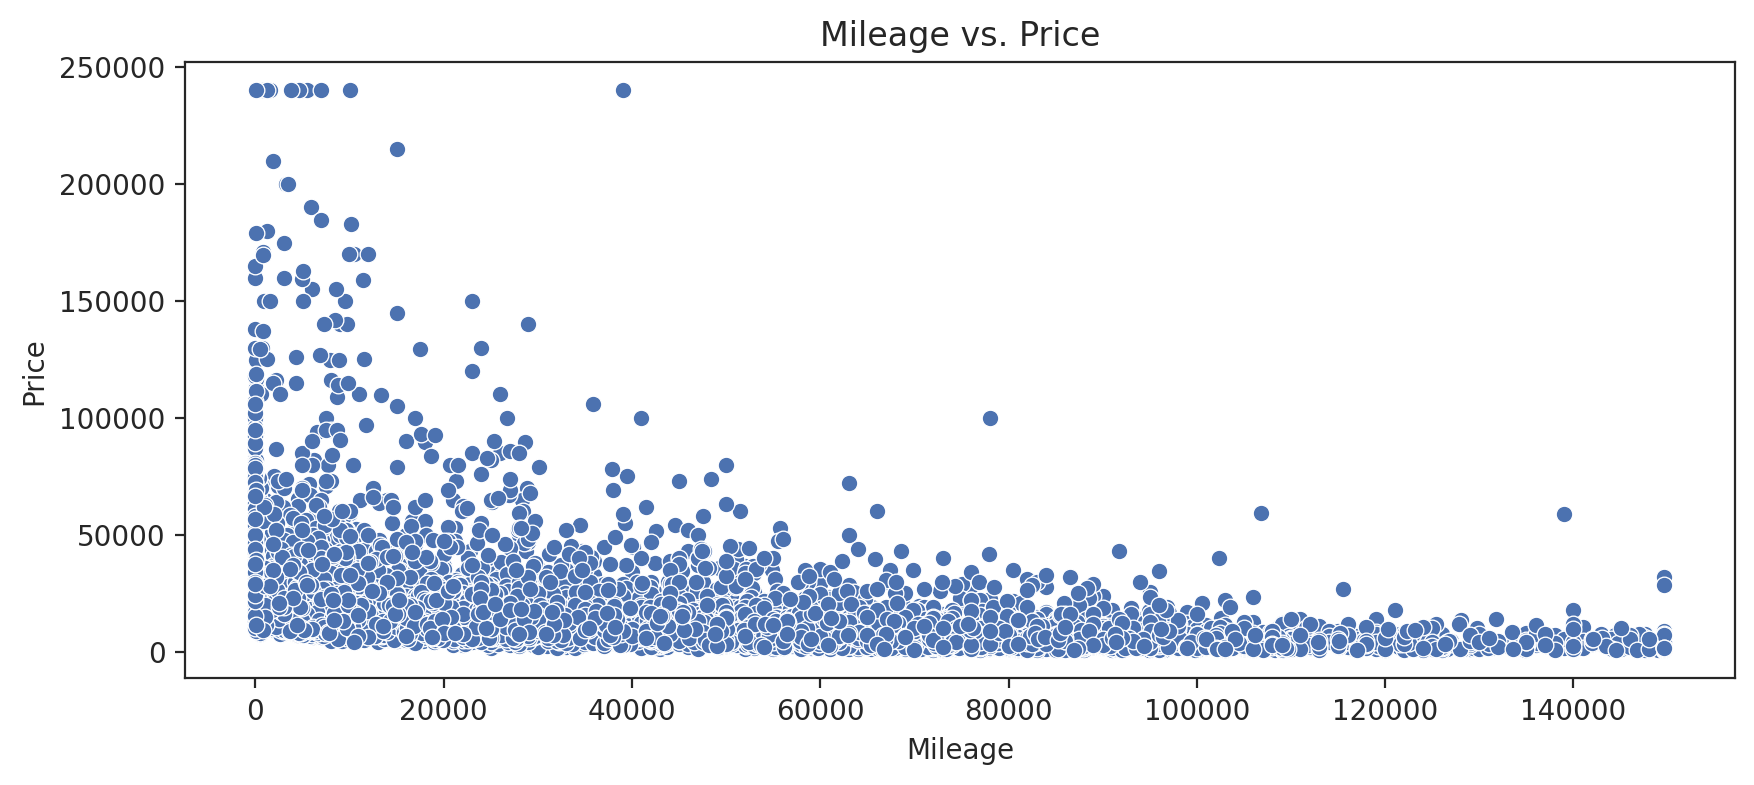

In [67]:
# prompt: scatterplot mileage against price

# Create the scatter plot
plt.figure(figsize=(10, 4))
sns.scatterplot(x='mileage', y='price', data=advt.sample(10000))
plt.title('Mileage vs. Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

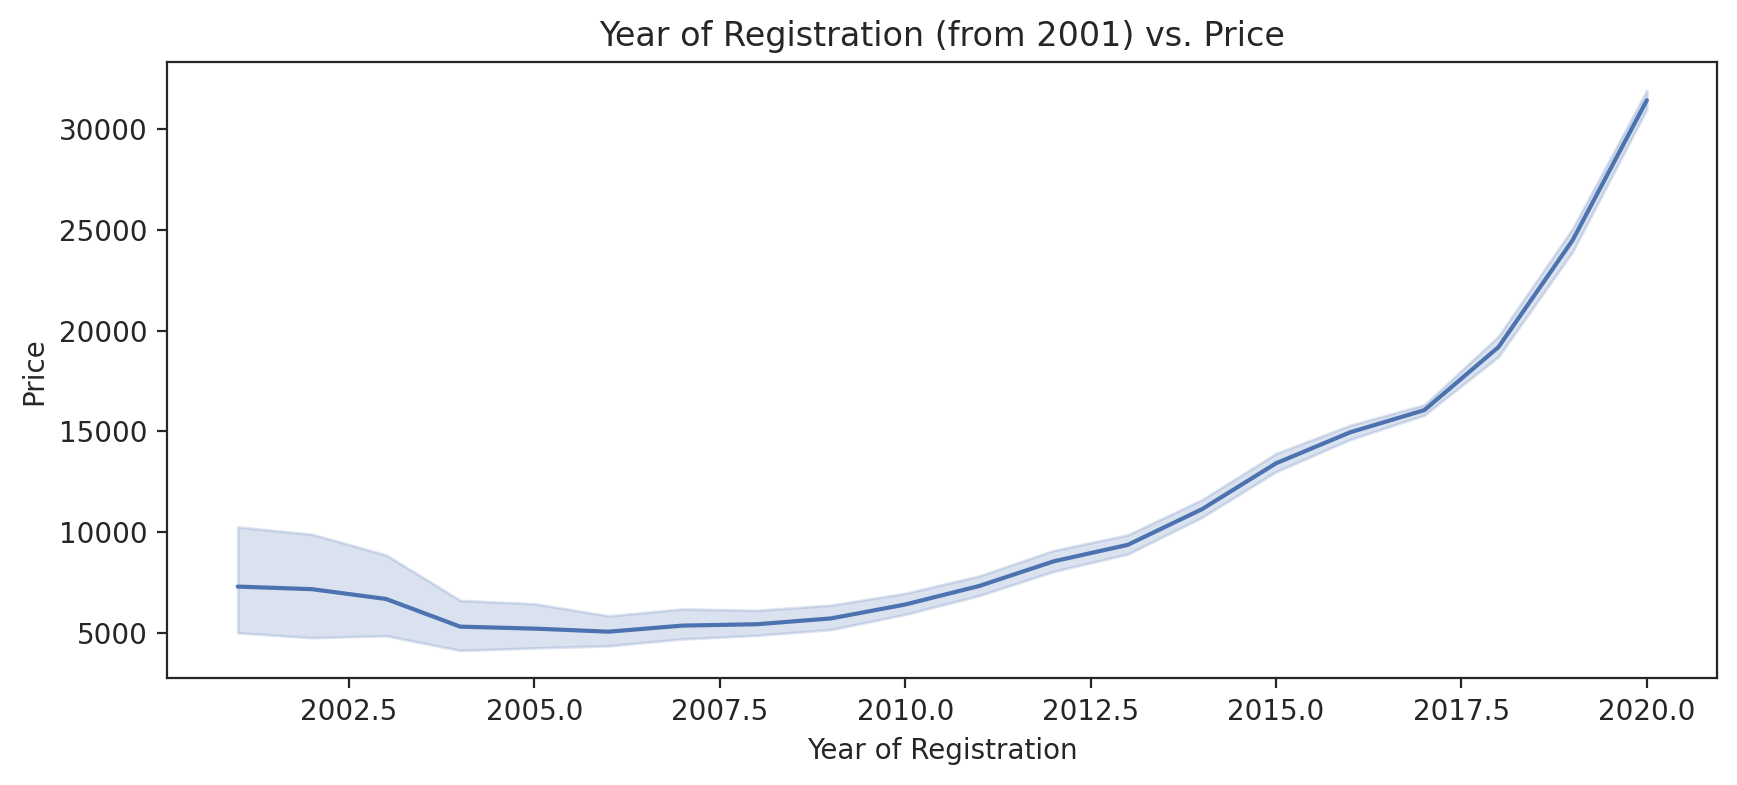

In [68]:
# lineplot of year_of_registration after 2000 against price

plt.figure(figsize=(10, 4))
sns.lineplot(x='year_of_registration', y='price', data=advt[advt['year_of_registration'] > 2000].sample(50000))
plt.title('Year of Registration (from 2001) vs. Price')
plt.xlabel('Year of Registration')
plt.ylabel('Price')
plt.show()

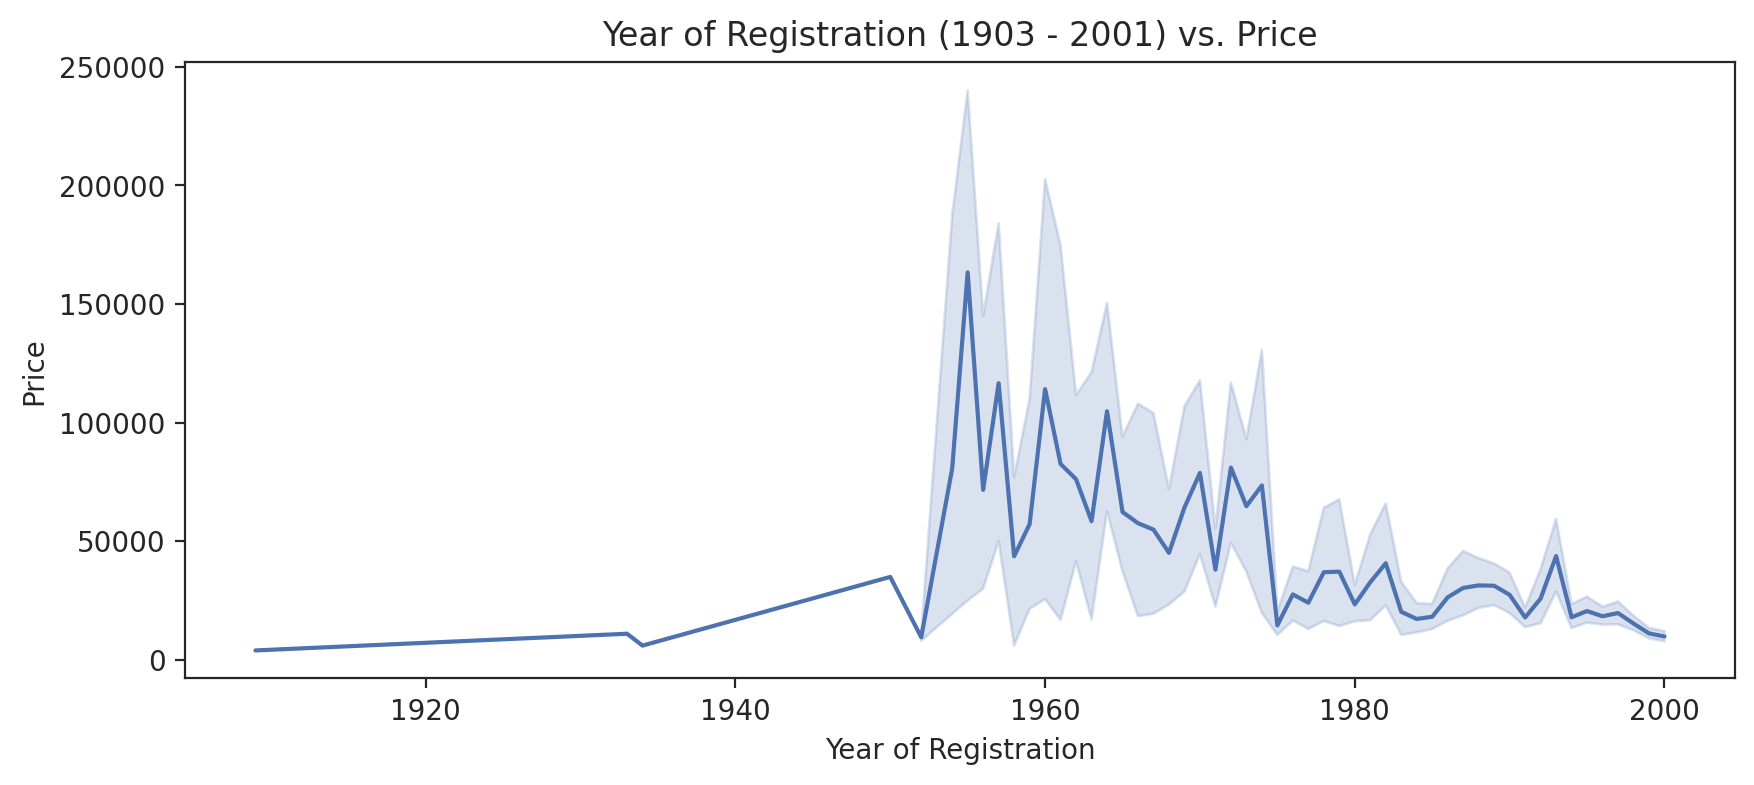

In [69]:
plt.figure(figsize=(10, 4))
sns.lineplot(x='year_of_registration', y='price', data=advt[advt['year_of_registration'] < 2001])
plt.title('Year of Registration (1903 - 2001) vs. Price')
plt.xlabel('Year of Registration')
plt.ylabel('Price')
plt.show()

In [70]:
advt[advt['year_of_registration'] < 1970]


,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age(in years),average_mileage,mileage_class
5045,33500.0,Blue,Land Rover,Series II,USED,1969.0,15970,Estate,False,Petrol,51.0,656.9,low
15575,45162.0,Silver,Daimler,SP,USED,1962.0,49995,Convertible,False,Petrol,58.0,778.7,low
19364,53824.0,White,Fiat,500,USED,1967.0,11000,Saloon,False,NaN,53.0,1015.5,low
20598,500.0,Green,MG,MGB GT,USED,1968.0,34995,Coupe,False,Petrol,52.0,9.6,low
24258,56109.0,Red,Jaguar,E-Type,USED,1964.0,119995,Coupe,False,Petrol,56.0,1001.9,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
396021,1975.0,Green,Aston Martin,DB2,USED,1954.0,240000,Saloon,False,Petrol,66.0,29.9,low
396557,6242.0,Black,Austin,Healey,USED,1965.0,88000,Coupe,False,Petrol,55.0,113.5,low
397962,86813.0,Blue,Fiat,Pininfarina,USED,1954.0,12500,Convertible,False,Petrol,66.0,1315.3,low
399633,93000.0,Blue,Land Rover,Series II,USED,1964.0,2500,SUV,False,Petrol,56.0,1660.7,low


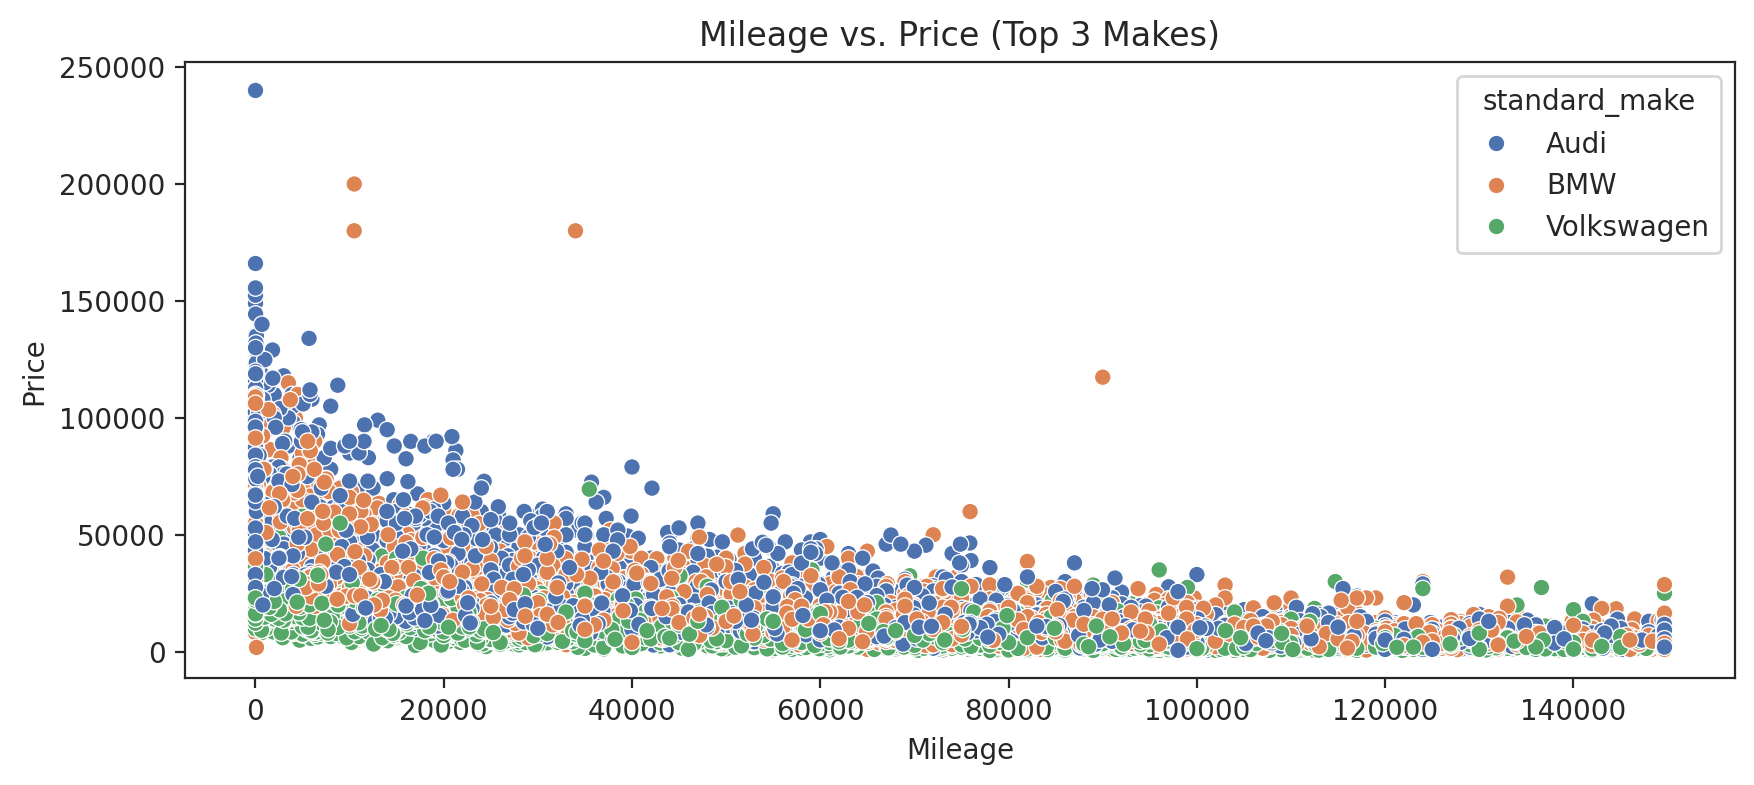

In [71]:
# Bubbleplot of mileage against price with most frequent standard_make.

top_3_makes = advt['standard_make'].value_counts().nlargest(3).index

plt.figure(figsize=(10, 4))
sns.scatterplot(x='mileage', y='price', hue='standard_make',
                data=advt[advt['standard_make'].isin(top_3_makes)].sample(50000))
plt.title('Mileage vs. Price (Top 3 Makes)')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

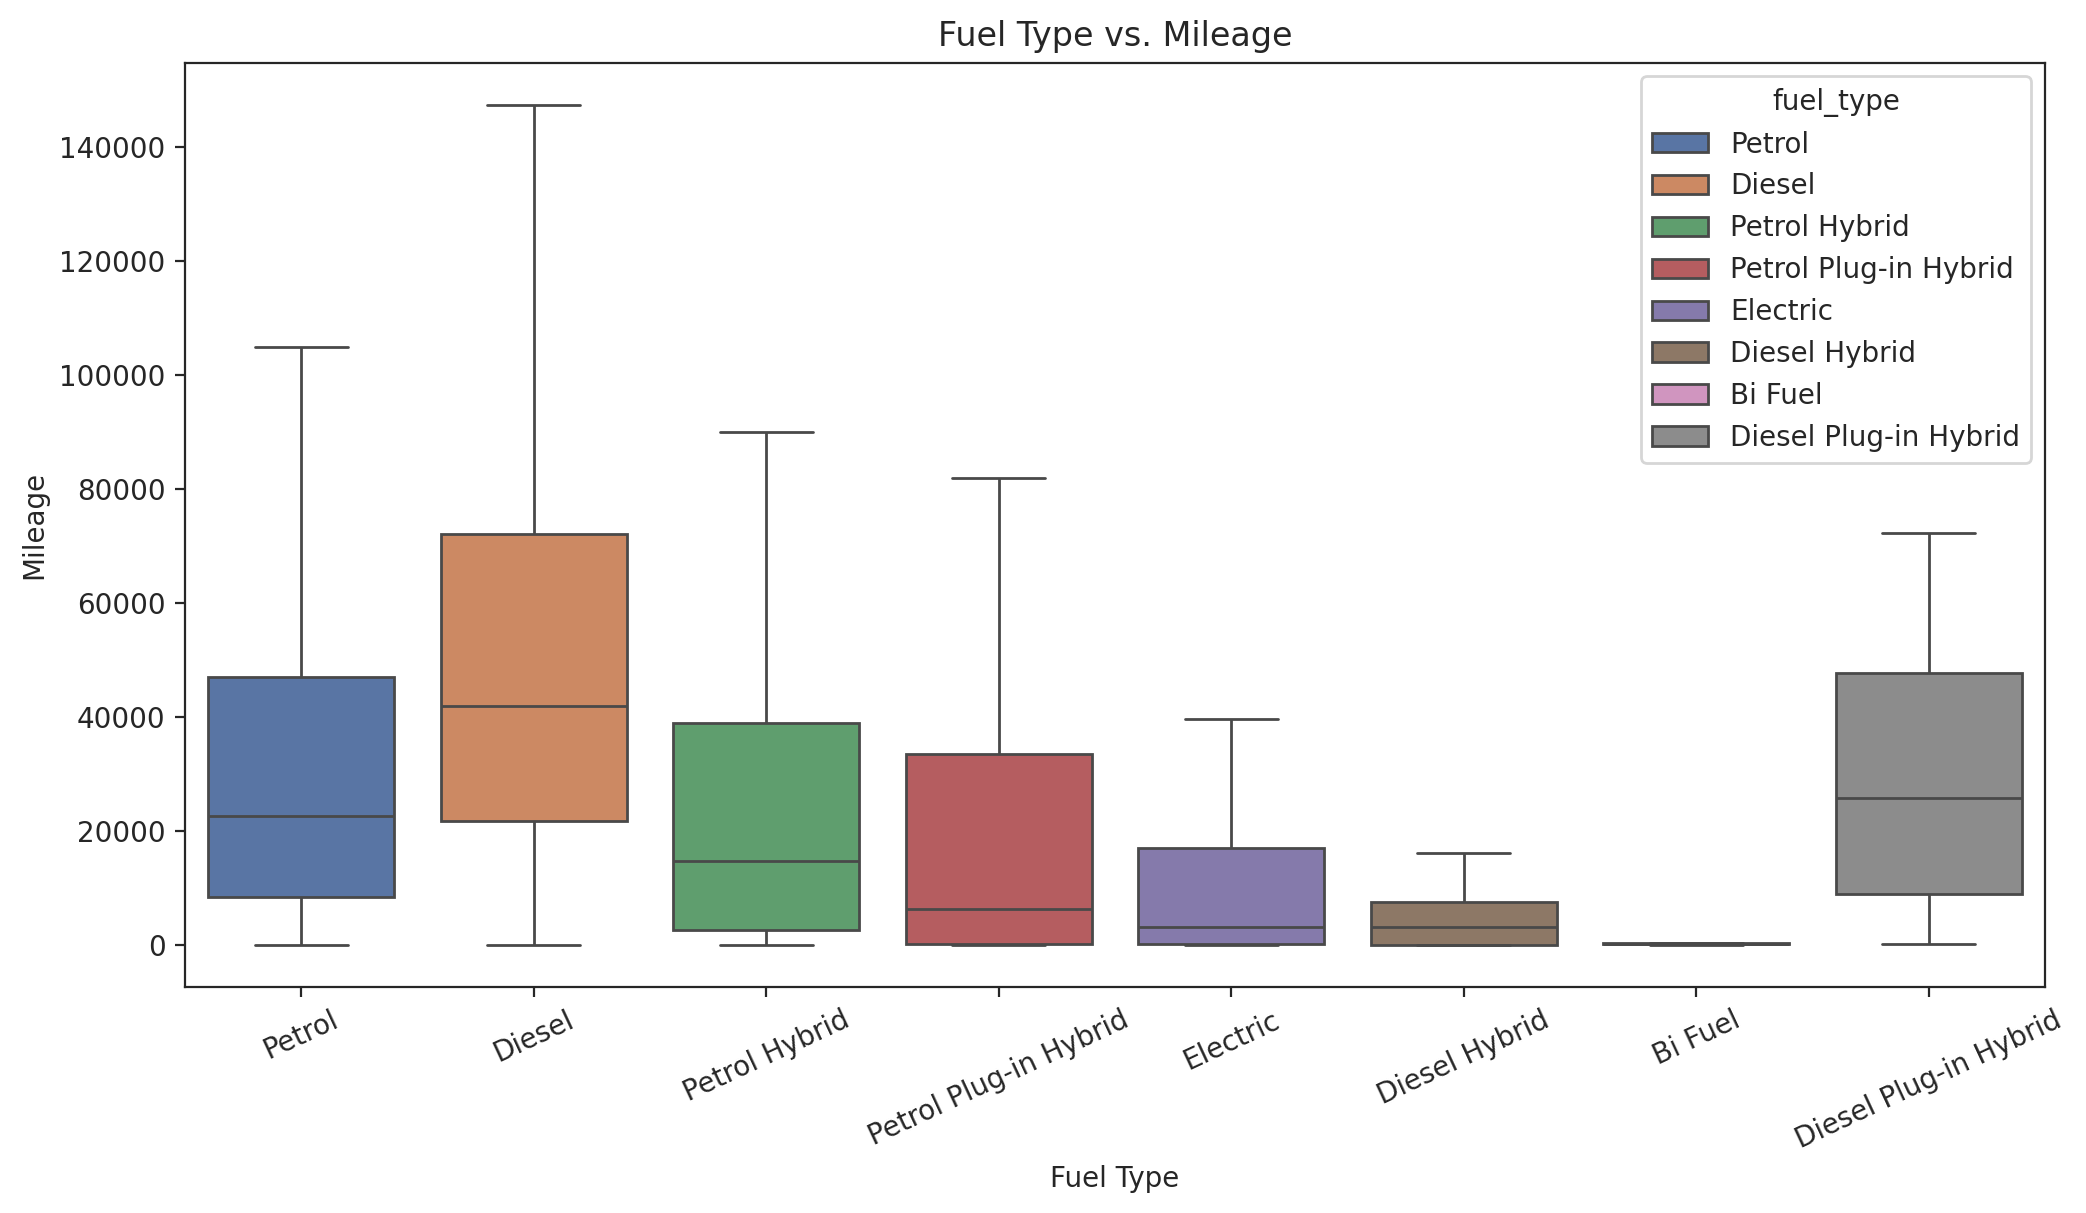

In [73]:
# Boxplot of fuel_type againsst price

plt.figure(figsize=(12, 6))
sns.boxplot(x='fuel_type', y='mileage', data=advt.sample(10000), showfliers=False, hue ='fuel_type')
plt.title('Fuel Type vs. Mileage')
plt.xlabel('Fuel Type')
plt.ylabel('Mileage')
plt.xticks(rotation=25)
plt.show()

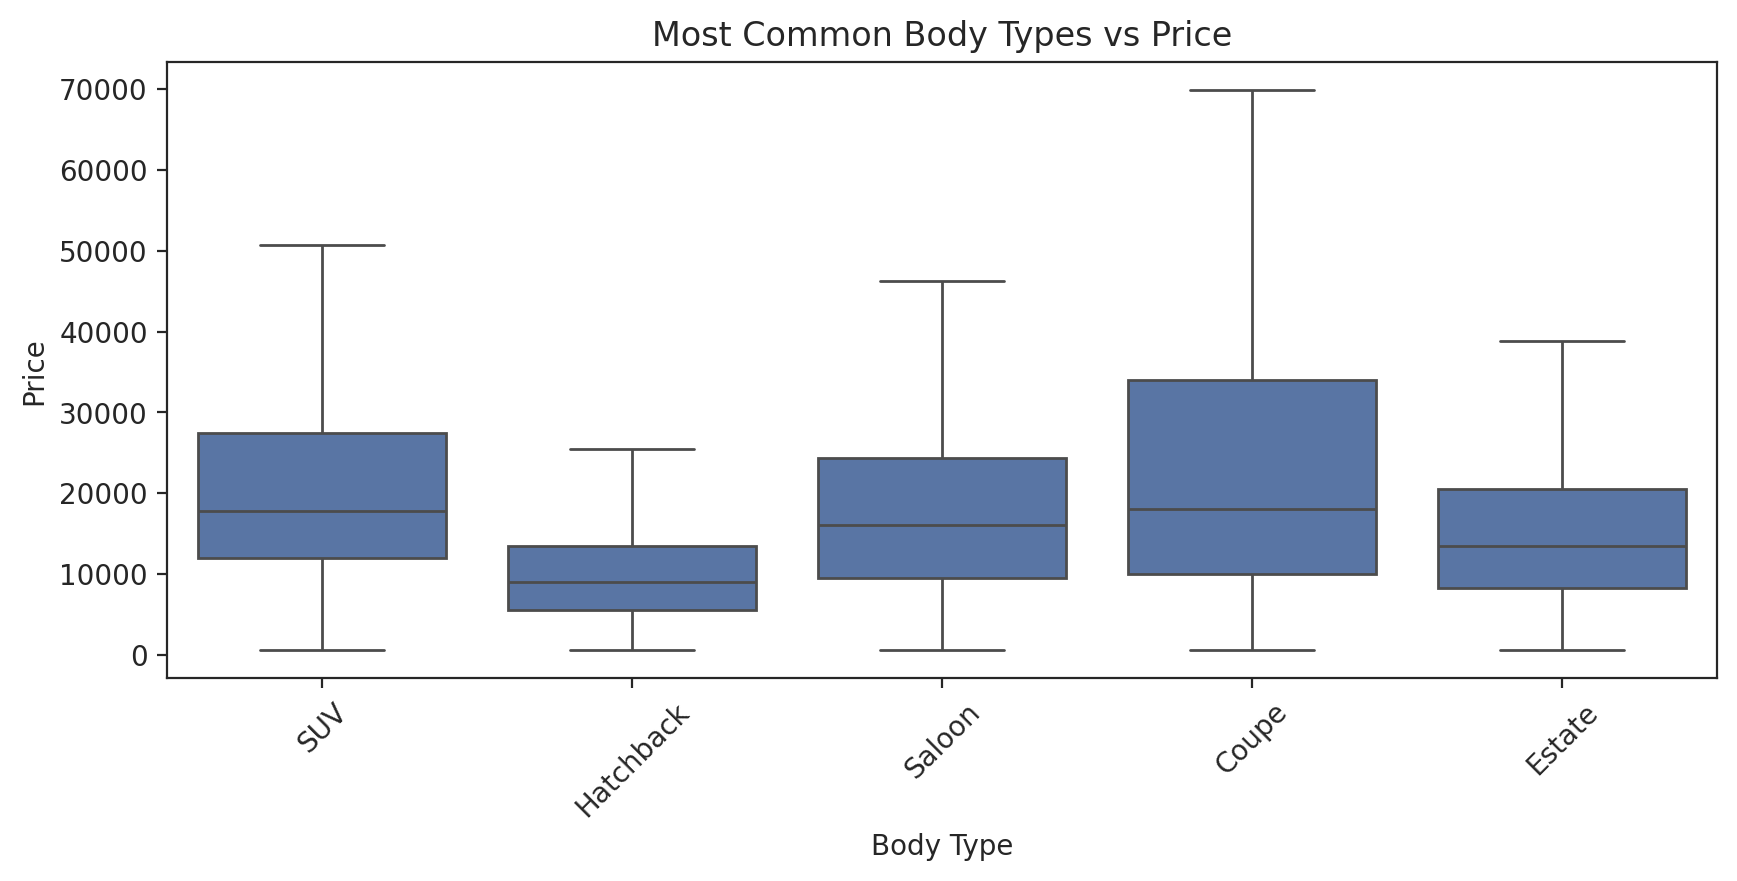

In [74]:
top_5_body_types = advt['body_type'].value_counts().nlargest(5).index

plt.figure(figsize=(10, 4))
sns.boxplot(x='body_type', y='price', data=advt[advt['body_type'].isin(top_5_body_types)].sample(50000), showfliers=False)
plt.xlabel("Body Type")
plt.ylabel("Price")
plt.title("Most Common Body Types vs Price")
plt.xticks(rotation=45)
plt.show()

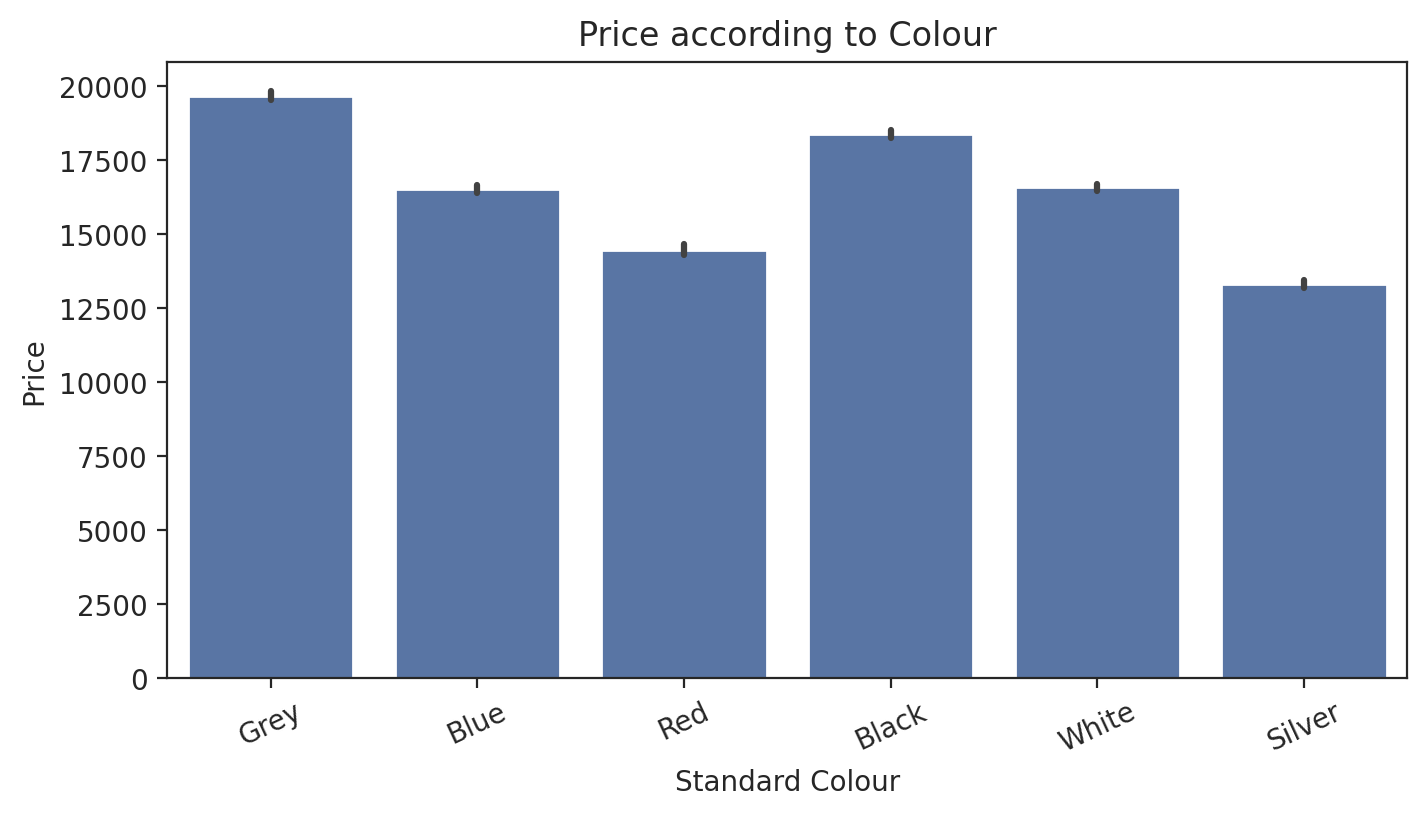

In [75]:
top_colours = advt['standard_colour'].value_counts().nlargest(6).index
plt.figure(figsize=(8,4))
ax=sns.barplot(data=advt[advt['standard_colour'].isin(top_colours)], x='standard_colour', y='price')
plt.title('Colour vs. Price')
plt.xlabel('Standard Colour')
plt.ylabel('Price')
plt.title('Price according to Colour')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25)
plt.show()


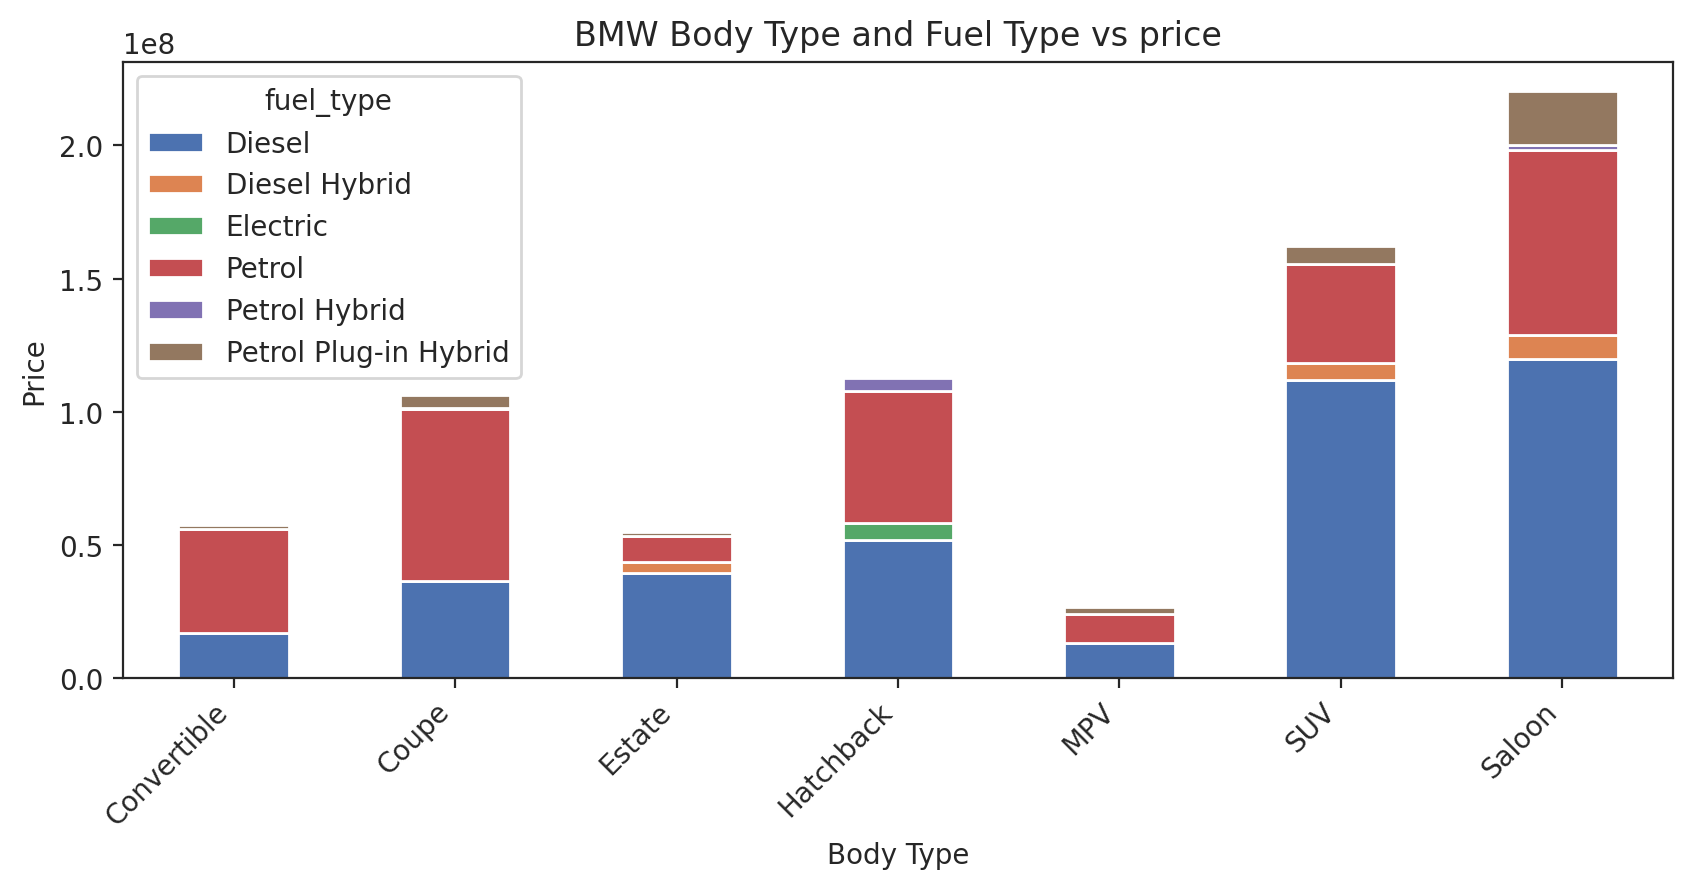

In [76]:

# Barplot of BMW body_type and fuel_type
grouped_data = sub_bmw.groupby(['body_type', 'fuel_type'])['price'].sum().unstack()
grouped_data.plot(kind='bar',stacked=True, figsize=(10,4));
plt.title('BMW Body Type and Fuel Type vs price')
plt.xlabel('Body Type')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.show()

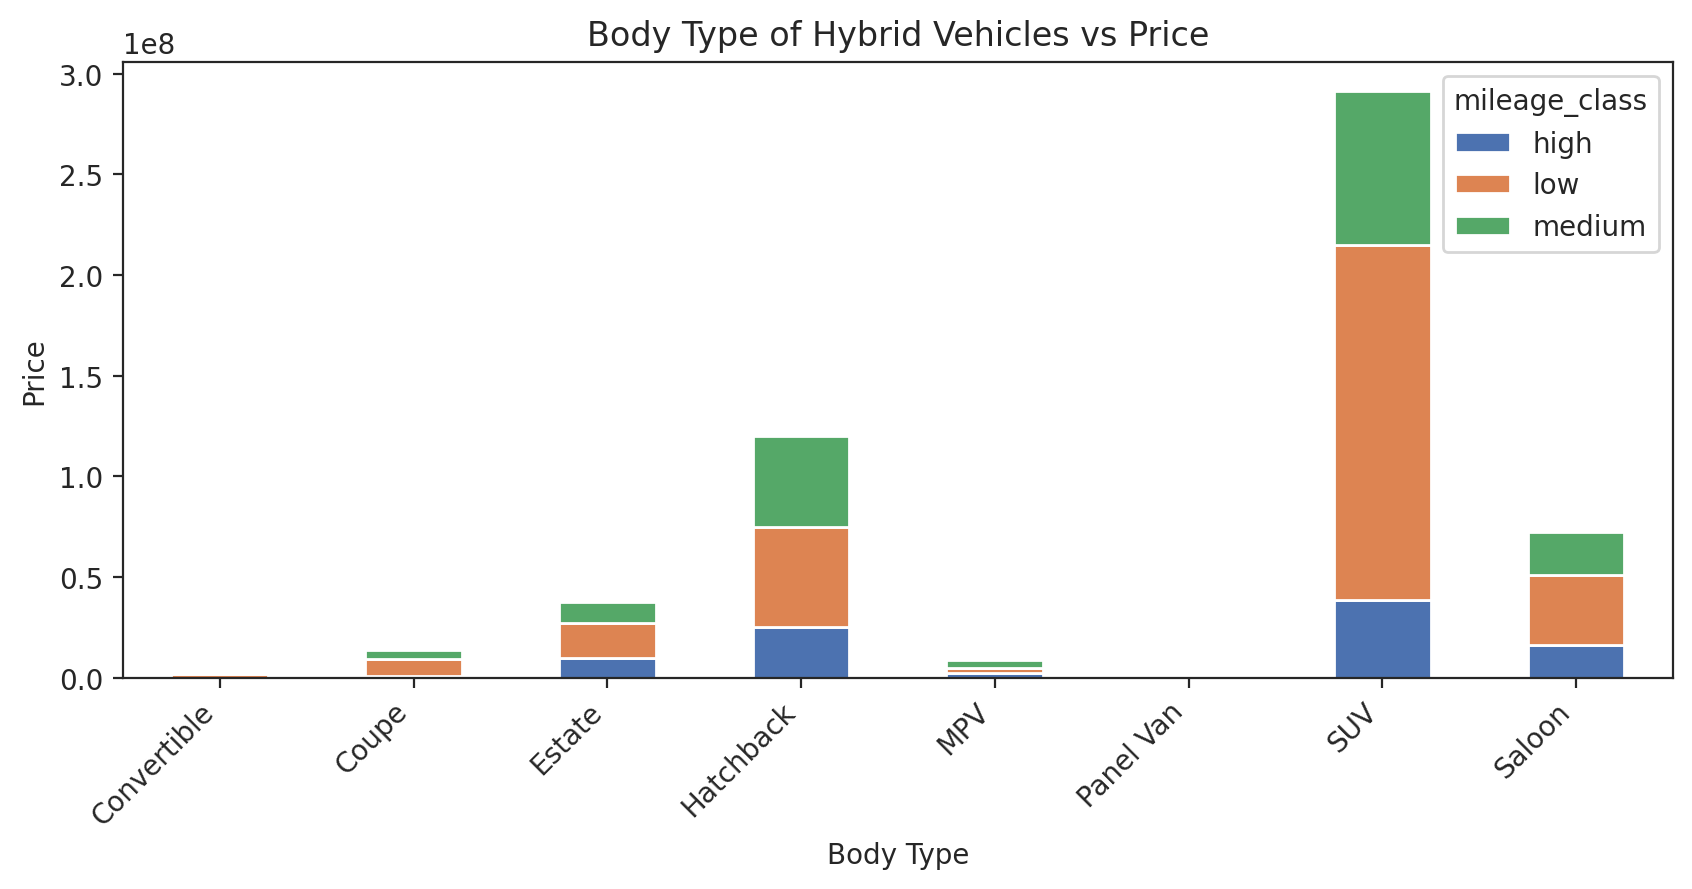

In [77]:
grouped_data = hybrid_cars.groupby(['body_type','mileage_class'])['price'].sum().unstack()
grouped_data.plot(kind='bar',stacked=True, figsize=(10,4));
plt.title('Body Type of Hybrid Vehicles vs Price')
plt.xlabel('Body Type')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.show()

In [78]:
hybrid_cars['body_type'].value_counts().head(3)

,count
body_type,
SUV,8779
Hatchback,7522
Saloon,2602
